# Genre Operational Synergy

The investment firm wants to identify which game genres have the strongest operational synergy based on publisher portfolios.

Because operational synergy can be defined in different ways, the analysis compares title-count similarity, owner-exposure similarity, and publisher overlap.


In [7]:
import re
import numpy as np
import pandas as pd

STEAM_PATH = "../../data/steam/steam.csv"

GENRES = [
    "Action", "Adventure", "Casual", "Indie",
    "RPG", "Strategy", "Simulation", "Sports",
]

steam = pd.read_csv(STEAM_PATH)

# Estimate owners from interval midpoint.
steam["owners_est"] = steam["owners"].apply(
    lambda x: np.mean([
        float(n) for n in re.findall(
            r"\d+", str(x).replace(",", "")
        )
    ])
)

# Expand genre and publisher assignments.
data = (
    steam.assign(
        genre=steam["genres"].fillna("").str.split(";"),
        publisher_name=steam["publisher"].fillna("").str.split(";"),
    )
    .explode("genre")
    .explode("publisher_name")
)

data["genre"] = data["genre"].str.strip()
data["publisher_name"] = data["publisher_name"].str.strip()

data = data[
    data["genre"].isin(GENRES)
    & data["publisher_name"].ne("")
].drop_duplicates(
    ["appid", "publisher_name", "genre"]
)

# Publisher × genre measures.
pg = (
    data.groupby(["publisher_name", "genre"])
    .agg(
        titles=("appid", "nunique"),
        owners=("owners_est", "sum"),
    )
    .reset_index()
)

titles = pg.pivot(
    index="publisher_name",
    columns="genre",
    values="titles",
).fillna(0).reindex(columns=GENRES, fill_value=0)

owners = pg.pivot(
    index="publisher_name",
    columns="genre",
    values="owners",
).fillna(0).reindex(columns=GENRES, fill_value=0)


def cosine(df):
    x = df.to_numpy()
    return (x.T @ x) / np.outer(
        np.linalg.norm(x, axis=0),
        np.linalg.norm(x, axis=0),
    )


def jaccard(df):
    x = (df.to_numpy() > 0).astype(int)
    intersection = x.T @ x
    counts = x.sum(axis=0)
    return intersection / (
        counts[:, None]
        + counts[None, :]
        - intersection
    )


def strongest(matrix):
    matrix = matrix.copy()
    np.fill_diagonal(matrix, np.nan)

    i, j = np.unravel_index(
        np.nanargmax(matrix),
        matrix.shape,
    )

    return GENRES[i], GENRES[j], matrix[i, j]


results = pd.DataFrame(
    [
        ["Title-count cosine", *strongest(cosine(titles))],
        ["Owner-exposure cosine", *strongest(cosine(owners))],
        ["Publisher-overlap Jaccard", *strongest(jaccard(titles))],
    ],
    columns=[
        "definition",
        "genre_1",
        "genre_2",
        "score",
    ],
)

print(results.round(3).to_string(index=False))

               definition   genre_1  genre_2  score
       Title-count cosine Adventure   Casual  0.724
    Owner-exposure cosine    Action Strategy  0.881
Publisher-overlap Jaccard    Action    Indie  0.520


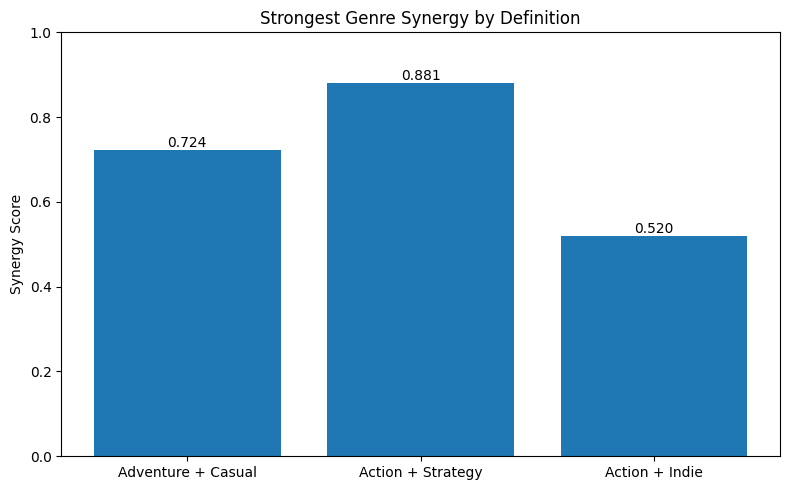

In [8]:
import matplotlib.pyplot as plt

labels = (
    results["genre_1"]
    + " + "
    + results["genre_2"]
)

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    labels,
    results["score"],
)

ax.set_title(
    "Strongest Genre Synergy by Definition"
)
ax.set_ylabel("Synergy Score")
ax.set_ylim(0, 1)

for bar, value in zip(
    bars,
    results["score"],
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"{value:.3f}",
        ha="center",
        va="bottom",
    )

plt.tight_layout()
plt.show()

## Conclusion

The strongest genre pair changes with the definition of operational synergy:

* Title-count similarity: **Adventure + Casual (0.724)**
* Owner-exposure similarity: **Action + Strategy (0.881)**
* Publisher overlap: **Action + Indie (0.520)**

The result therefore depends on how operational synergy is defined.
